In this notebook we simulate future stock prices, risk-free rates, 3 year bonds and sharpe ratios from 31 october 2014 to 31 october 2033. We assume that the voatility follows stockastic process (Heston Model). We assume that other 

## Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import market_stochastic_simulation as mss
import retirement_client as pensioner

# 1. Market Simulation Code

$
\begin{cases}
r_{t+dt} = r_t + \kappa_r (\bar{lt_r} - r_t) dt + \sigma_r \sqrt{dt} Z_t^r\\
SR_{t+dt} = SR_t + \kappa_sr (\bar{lt_sr} - SR_t) dt + \sigma_SR \sqrt{dt} Z_t^SR\\
V_{t+dt} = V_t + \kappa_v (lt_V - V_t) dt + \sigma_V \sqrt{V_t} \sqrt{dt} Z_t^V\\
S_{t+dt} = S_t \times \exp \left( \left( r + \bar{\lambda_0} \sigma_t - \frac{1}{2} \sigma_t^2 \right) dt + \sigma_t \sqrt{dt} Z_t^S \right) \\
\end{cases}
$

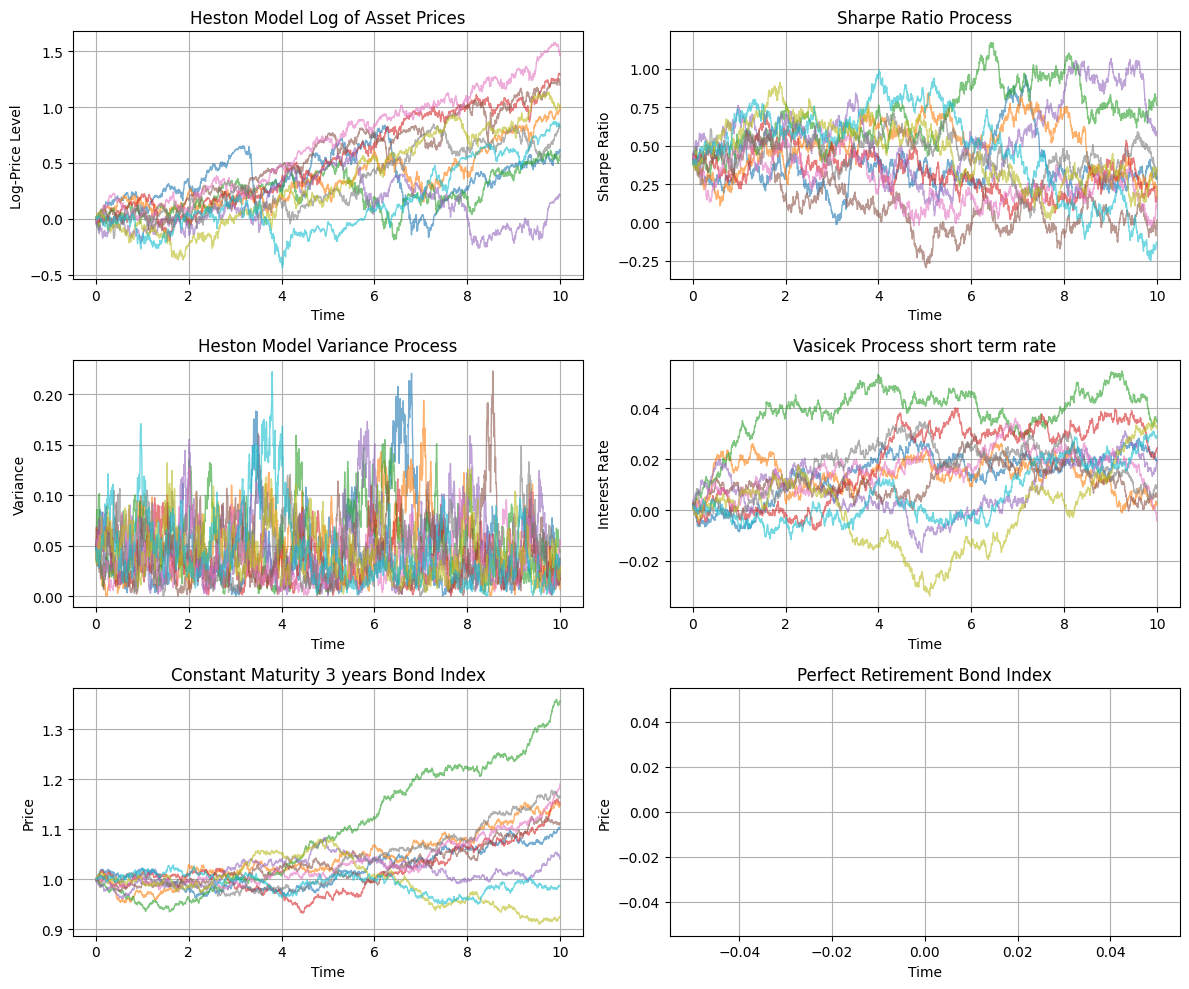

In [2]:
# Parameters
S0 = 1.0              # asset price
T = 10                  # time in years
N = 252*T              # number of time steps in simulation
M = 10                # number of simulated paths
seed = 123              # simulation seed

simulated_market = mss.MarketSimulator(T,N,M,seed, S0)
simulated_market.plot_market_simulation()

## Initialize client

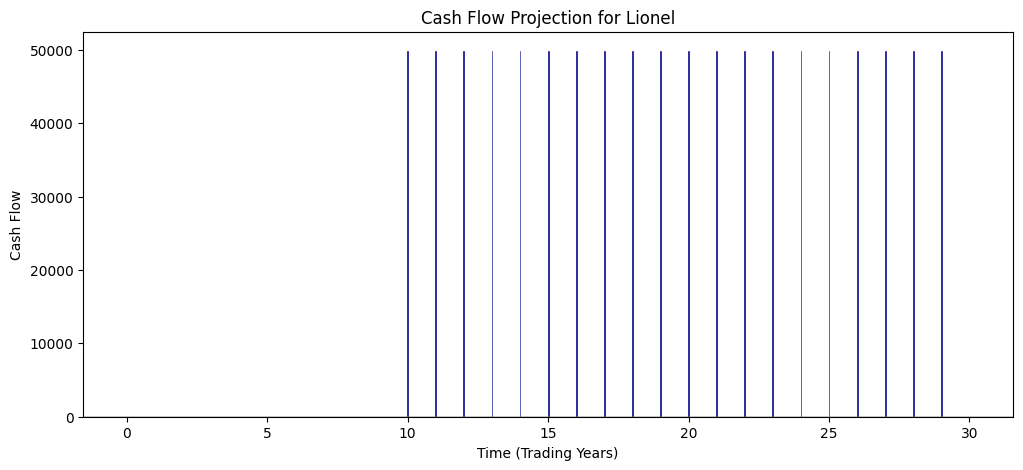

In [3]:
client = pensioner.RetirementClient("Lionel",
                           accumulation_years=10,
                           accumulation_cash_flow=0,
                           decumulation_years=20,
                           decumulation_cash_flow=50000,
                           periodicity = 12)

client.plot_cash_flows()

Now we know cash flows that the client needs. Hence, we can simulate perfect retirement bond for him

In [4]:
simulated_market.calculate_perfect_retirement_bond(client)

Simulating scenarios: 100%|█████████████████████| 10/10 [00:00<00:00, 89.72it/s]


Plot the market and the retirement bond index. If you would use M = 31, you would get full retirement bond price with ladder

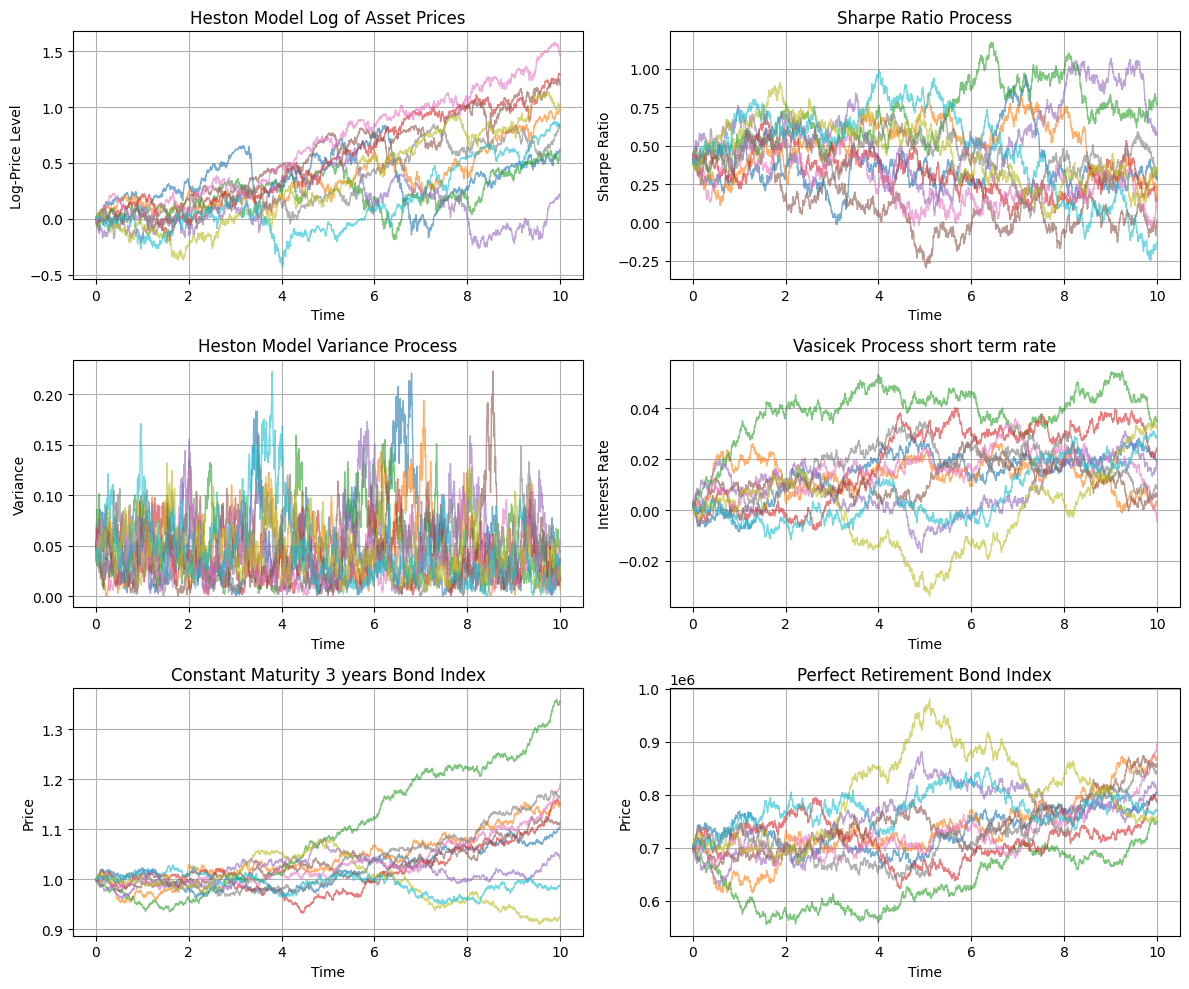

In [5]:
simulated_market.plot_market_simulation()

## Set up a fund

In [6]:
class FundAllocationSimulator:
    def __init__(self, initial_savings, retirement_bond_p, r_p):
        """
        Initializes the FundAllocationSimulator class with initial savings, 
        retirement bond price data, and short-term interest rates.
        
        Parameters:
        - initial_savings (float): The initial amount invested by the individual.
        - retirement_bond_p (DataFrame): The retirement bond price data (simulated).
        - r_p (DataFrame): The short-term interest rates for the simulations.
        """
        self.initial_savings = initial_savings
        self.retirement_bond_p = retirement_bond_p
        self.r_p = r_p
        
        # Calculate the percentage change of the retirement bond price to get RL (Retirement Liability)
        self.RL = self.retirement_bond_p.pct_change().dropna()

        # Drop the first observation of r_p to match the alignment after pct_change
        self.r_p = self.r_p.drop(self.r_p.index[0])
        
        # Initialize an empty results DataFrame
        self.results_df = pd.DataFrame(columns = ['simulation_M',
                                                  'x',
                                                  'GHP',
                                                  'rebalance_each_X_periods',
                                                  'total_return',
                                                  'annualized_return',
                                                  'MDD',
                                                  'annualized_tracking_err'])
        
    def balanced_fund(self, PSP, GHP, x, rebalance_each_X_periods):
        """
        Simulates a portfolio with a mix of two assets, PSP and GHP, based on an investment weight x.
        
        Parameters:
        - PSP: DataFrame of asset prices (e.g., stock prices).
        - GHP: DataFrame of asset prices (e.g., bond prices).
        - x: Float (0 <= x <= 1) representing the weight for PSP. The remaining weight is allocated to GHP.
             It does not have restriction to be less than 0 or higher than 1 in code, so maybe this can happen
             If it happens there will be alert raised
        - rebalance_each_X_periods: int or str, Frequency at which to rebalance the portfolio
            If parameter = 2, for instance, rebalancing weill be done every other period (trading days, for instance)
            If parameter = 21, rebalancing will be done every 21st period (every 21st day if we have days)
            If parameter = "no_rebalancing", there is NO REBALANCING
            
        Returns:
        - DataFrame containing the portfolio weights of PSP over time.
        - DataFrame containing the total portfolio returns (of PSP and GHP)
        - DataFrame containing the weight changes for transaction costs
        """
        
        # Step 1: Calculate returns for PSP and GHP
        psp_returns = PSP.pct_change()  # Percentage change of the index price, leave NaNs
        ghp_returns = GHP.pct_change()  # Percentage change of the index price, leave NaNs
        
        # Step 2: Create a DataFrame to hold the PSP weights in portfolio
        psp_weights = pd.DataFrame(index=PSP.index, columns=PSP.columns)
        
        # Step 3: Create a DataFrame to hold the portfolio returns over time
        portfolio_returns = pd.DataFrame(index=PSP.index, columns=PSP.columns)
        
        # Step 4: Create a DataFrame to hold the weight values at rebalancing dates
        weight_change_for_tr_costs_psp = pd.DataFrame(index=PSP.index, columns=PSP.columns).fillna(0)
        
        # Step 5: Portfolio simulation
        # Weights are initially set to x for PSP
        # All weights for the first time step are based on x (1-x for GHP)
        psp_weights.iloc[0, :] = x
        periods_till_rebalancing = rebalance_each_X_periods
        
        for i in range(1, len(PSP)):
            portfolio_returns.iloc[i,:] = psp_weights.iloc[i-1, :] * psp_returns.iloc[i,:] + \
            (1 - psp_weights.iloc[i-1, :]) * ghp_returns.iloc[i,:]
        
            # find new value for PSP and GHP that are based on the returns
            PSP_new_value = psp_weights.iloc[i-1, :] * (1 + psp_returns.iloc[i,:])
            GHP_new_value = (1 - psp_weights.iloc[i-1, :]) * (1 + ghp_returns.iloc[i,:])
            # find total new value of portfolio
            total_portfolio_new_value = PSP_new_value + GHP_new_value
        
            # new drifted weight of PSP is the value of the PSP in total portfolio value
            psp_new_weight = PSP_new_value / total_portfolio_new_value
        
            if rebalance_each_X_periods != "no_rebalancing":
                # if there is rebalancing and it is date of rebalancing today
                periods_till_rebalancing -=1
                if periods_till_rebalancing == 0:
        
                    # then we need to store the change in weights for transaction costs modeling
                    weight_change_for_tr_costs_psp.iloc[i,:] = x - psp_new_weight
        
                    # and put instead of the calculated weights for the new period weights at rebalancing date
                    psp_weights.iloc[i, :] = x
        
                    # reset preiods_till_rebalancing to initial value
                    periods_till_rebalancing = rebalance_each_X_periods
                    
                else:
                    # otherwise, if it is not rabalancing date today just update the weights
                    psp_weights.iloc[i, :] = psp_new_weight
            else:
                # otherwise, if we do not rebalance at all, just update the weights
                psp_weights.iloc[i, :] = psp_new_weight
            
            # Note that in this code return_portfolio = return_assets_t+1*w_t
            # It assures out-of-sample calculation
                
            # Also note that w_t+1 is found using returns of the new period. 
            # It is correct to drift weights like that.
        
            # Finally note that at rebalancing date T there are 2 weights:
            # weight w_T that has drifted from the previous period and 
            # weight w_T = x (initial weight in balanced fund).
            # I save only w_T = x in weights_psp for correctness of portfolio
            # returns calculation
            # I also save x-psp_new_weight to know what was the move for rebalancing: buy / sell and how much
    
        # psp_weights will Have no NaN values
        # portfolio_returns will have 1st row of NaNs
        # to find portfolio_returns artificially do psp_weights.shift(1)*psp_return + (1-psp_weights.shift(1))*hgp_return 
        return portfolio_returns, psp_weights, weight_change_for_tr_costs_psp

    def tracking_error(self, fund_returns, periods_in_year):
        """
        Calculate the tracking error between the fund's returns and the retirement liability (RL).
        
        Parameters:
        - fund_returns (DataFrame): The returns of the balanced fund
        
        Returns:
        - tracking_error (float): The tracking error of the portfolio
        """
        return np.std(fund_returns - self.RL) * np.sqrt(periods_in_year)

    def calculate_max_drawdown(self, fund_returns):
        # Compute the cumulative returns
        cumulative_returns = (fund_returns+1).cumprod()-1
    
        # Calculate the running maximum of the cumulative returns
        running_max = cumulative_returns.cummax()
    
        # Calculate the drawdown (percentage decline from the running max)
        drawdown = (cumulative_returns - running_max)
    
        # Calculate the maximum drawdown
        max_drawdown = drawdown.min()
    
        return max_drawdown

    def run_simulation(self, PSP, GHP_options, x_options, rebalancing_options, periods_in_year):
        """
        Runs multiple simulations for different x values and rebalance frequencies.
        
        Parameters:
        - PSP (DataFrame): The dataset containing the asset prices of the PSP over time.
        - GHP (DataFrame): The dataset containing the asset prices of the GHP over time.
        - x_options (array): A series of values representing the different weights to invest in PSP.
        - rebalance_options (array): A series of rebalance frequencies to test (each Nth period will be done rebalancing)
        - periods_in_year is how many periods are in each year in PSP and GHP. For example, for yearly observations put 1
                                                                               for monthly 12, for daily 252
        
        Returns:
        - self.results_df (DataFrame): A DataFrame containing results for each simulation scenario.
        """

        # number of market pre-simulated scenarios
        # in code related to market simulation this is called M
        number_of_simulations = len(PSP.columns)
        n_ghp = 1
        for GHP in tqdm(GHP_options):
            for x in x_options:
                for rebalance_each_X_periods in rebalancing_options:
                    # Run the balanced fund simulation
                    returns_of_fund, _, _ = self.balanced_fund(PSP, GHP, x, rebalance_each_X_periods)
                    
                    # Calculate annualized return
                    total_return = (returns_of_fund+1).prod()-1
                    annualized_return = (1 + total_return) ** (1 / (len(returns_of_fund) / periods_in_year)) - 1
                    
                    # Calculate variance of fund return (annualized)
                    annualized_volatility = np.std(returns_of_fund) * np.sqrt(periods_in_year)
                    
                    # Calculate Sharpe ratio
                    annualized_mdd = self.calculate_max_drawdown(returns_of_fund)
                    
                    # Calculate tracking error
                    annualized_tracking_err = self.tracking_error(returns_of_fund, periods_in_year)
            
                    # Store the results in the dataframe
                    rebalance_each_X_periods = np.repeat(rebalance_each_X_periods, number_of_simulations)
                    
                    new_results_to_store = pd.DataFrame({
                                                        'simulation_M': PSP.columns,
                                                        'x': np.repeat(x, number_of_simulations),
                                                        'GHP': np.repeat('GHP_'+str(n_ghp), number_of_simulations),
                                                        'rebalance_each_X_periods': rebalance_each_X_periods,
                                                        'annualized_volatility': annualized_volatility,
                                                        'total_return':total_return,
                                                        'annualized_return': annualized_return,
                                                        'MDD': annualized_mdd,
                                                        'annualized_tracking_err': annualized_tracking_err
                                                        })
                    # update global dataframe                                        
                    self.results_df = pd.concat([self.results_df, new_results_to_store], ignore_index=True)
            n_ghp +=1

In [7]:
fund_allocation_simulator = FundAllocationSimulator(initial_savings = 287000,
                                                    retirement_bond_p = simulated_market.retirement_bond_p,
                                                    r_p = simulated_market.r_p)

In [8]:
# To the function; or to generate results for 1 balanced fund
returns_of_fund, weights_of_assets, _ = fund_allocation_simulator.balanced_fund(PSP = simulated_market.S_p,
                                                                               GHP = simulated_market.B_p, 
                                                                               x = 0.5, 
                                                                               rebalance_each_X_periods = 'no_rebalancing')

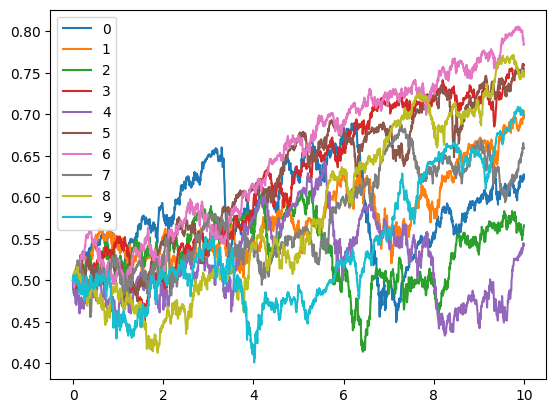

In [9]:
weights_of_assets.loc[:,:10].plot();

In [10]:
# To the function; or to generate results for 1 balanced fund
returns_of_fund2, weights_of_assets2, _ = fund_allocation_simulator.balanced_fund(PSP = simulated_market.S_p,
                                                                               GHP = simulated_market.B_p, 
                                                                               x = 0.5, 
                                                                               rebalance_each_X_periods = 21)

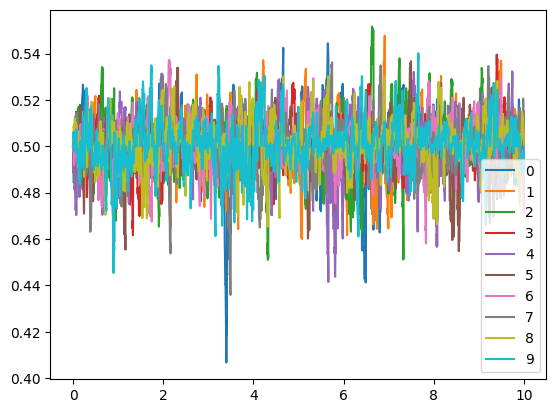

In [11]:
weights_of_assets2.loc[:,:10].plot();

In [12]:
fund_allocation_simulator.run_simulation(PSP = simulated_market.S_p,
                                           GHP_options = [simulated_market.B_p,simulated_market.retirement_bond_p], 
                                           x_options= np.arange(0,1.01,0.05), 
                                           rebalancing_options= ['no_rebalancing',21], # no rebalancing vs each 21 day rebalancing
                                           periods_in_year = int(simulated_market.N / simulated_market.T)
                                        )

100%|█████████████████████████████████████████████| 2/2 [03:01<00:00, 90.94s/it]


In [13]:
fund_allocation_simulator.results_df['x'].unique()

array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
       0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ])

In [14]:
def plot_tracking_error_histograms_separate(df, initial_investment):
    """
    Plots separate histograms of tracking errors and total returns for each rebalance frequency.
    
    Parameters:
    - df (DataFrame): The dataframe containing the simulation results.
    """
    
    # Get unique values of rebalance_each_X_periods
    rebalance_options = list(df['rebalance_each_X_periods'].unique())
    GHP_options = list(df['GHP'].unique())
    
    for GHP in GHP_options:
        # Loop through each rebalance option
        for rebalance in rebalance_options:
            # Filter the data for the current rebalance option
            filtered_data = df.loc[(df['rebalance_each_X_periods'] == rebalance) & (df['GHP'] == GHP),:]
            
            # Create subplots: 1 row, 2 columns (one for tracking error and one for total return)
            fig, axes = plt.subplots(1, 2, figsize=(14, 6))
            
            # Define a color palette for 'x' values
            colors = sns.color_palette("Set1", n_colors=len(filtered_data['x'].unique()))

            # Plot histograms for Tracking Error
            for idx, x in enumerate(sorted(fund_allocation_simulator.results_df['x'].unique())[1::5]):
                x_data = filtered_data[filtered_data['x'] == x]
                sns.histplot(x_data['annualized_tracking_err'], kde=True, bins=50, label=f"x = {x.round(2)}", ax=axes[0], color=colors[idx])
            
            axes[0].set_title(f"Tracking Error Distribution for Rebalance Periods={rebalance} and GHP = {GHP}")
            axes[0].set_xlabel("Annualized Tracking Error")
            axes[0].set_ylabel("Frequency")
            axes[0].legend(title="x Value")
            axes[0].grid(True)
    
            # Plot histograms for Total Return
            for idx, x in enumerate(sorted(fund_allocation_simulator.results_df['x'].unique())[1::5]):
    
                x_data = filtered_data[filtered_data['x'] == x]
                sns.histplot((x_data['total_return']+1)*initial_investment, kde=True, bins=50, label=f"x = {x.round(2)}", ax=axes[1], color=colors[idx], stat="density")
    
                # Add a vertical line for the mean of total return on the second plot
                median_total_return = ((x_data['total_return']+1)*initial_investment).median()
                axes[1].axvline(median_total_return, linestyle='dashed', linewidth=2, color=colors[idx], label=f"Median of {x.round(2)} TR: {median_total_return:.2f}")
        
            axes[1].set_title(f"Total Return Distribution for Rebalance Periods={rebalance} and GHP = {GHP}")
            axes[1].set_xlabel("Total Return")
            axes[1].set_ylabel("Frequency")
            axes[1].legend(title="x Value")
            axes[1].grid(True)
            axes[1].set_xlim(50, 400)
    
            # Show the plots
            plt.tight_layout()
            plt.show()


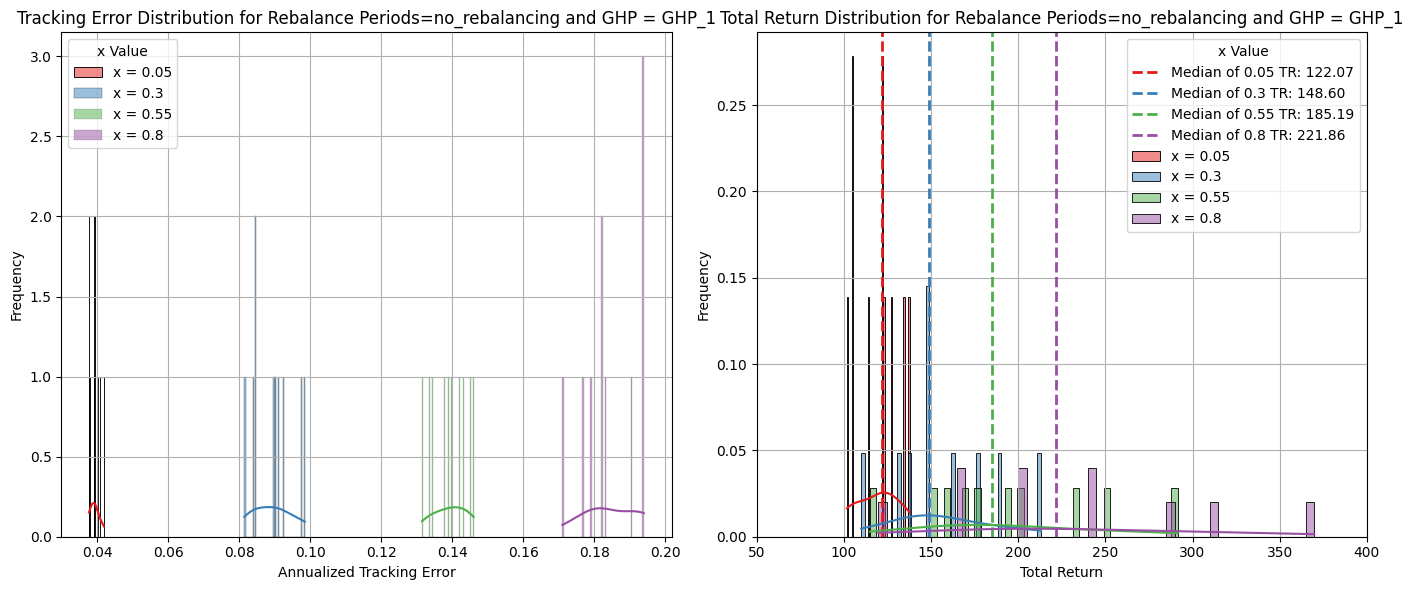

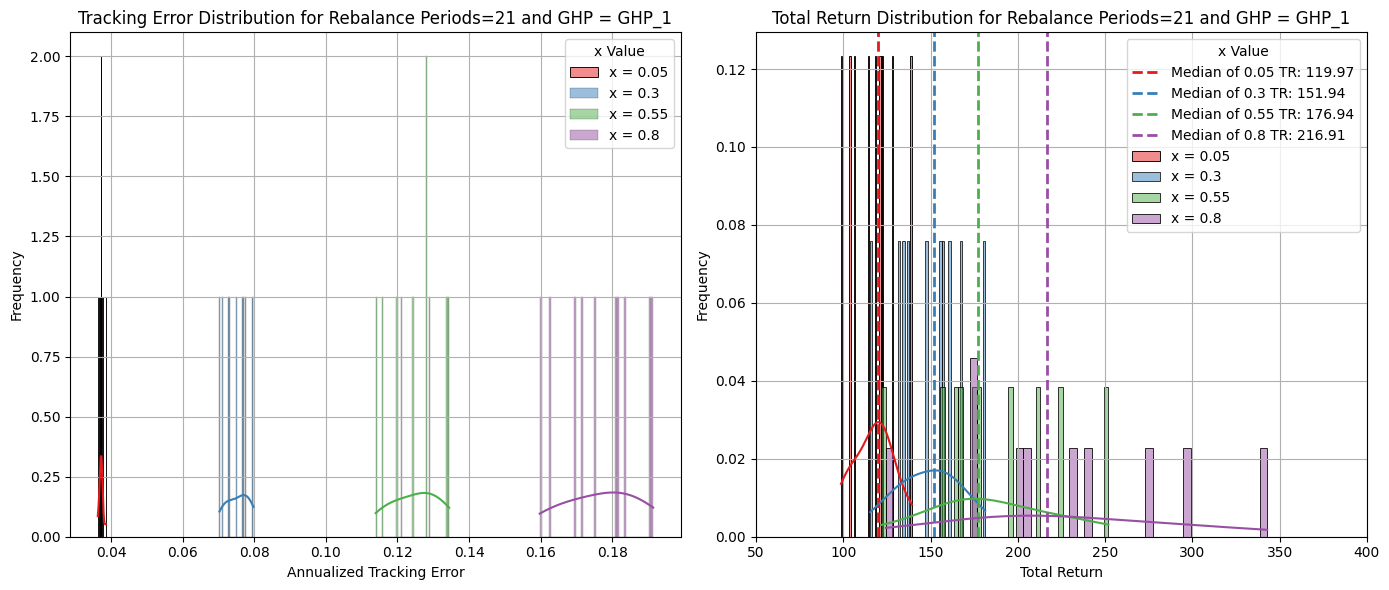

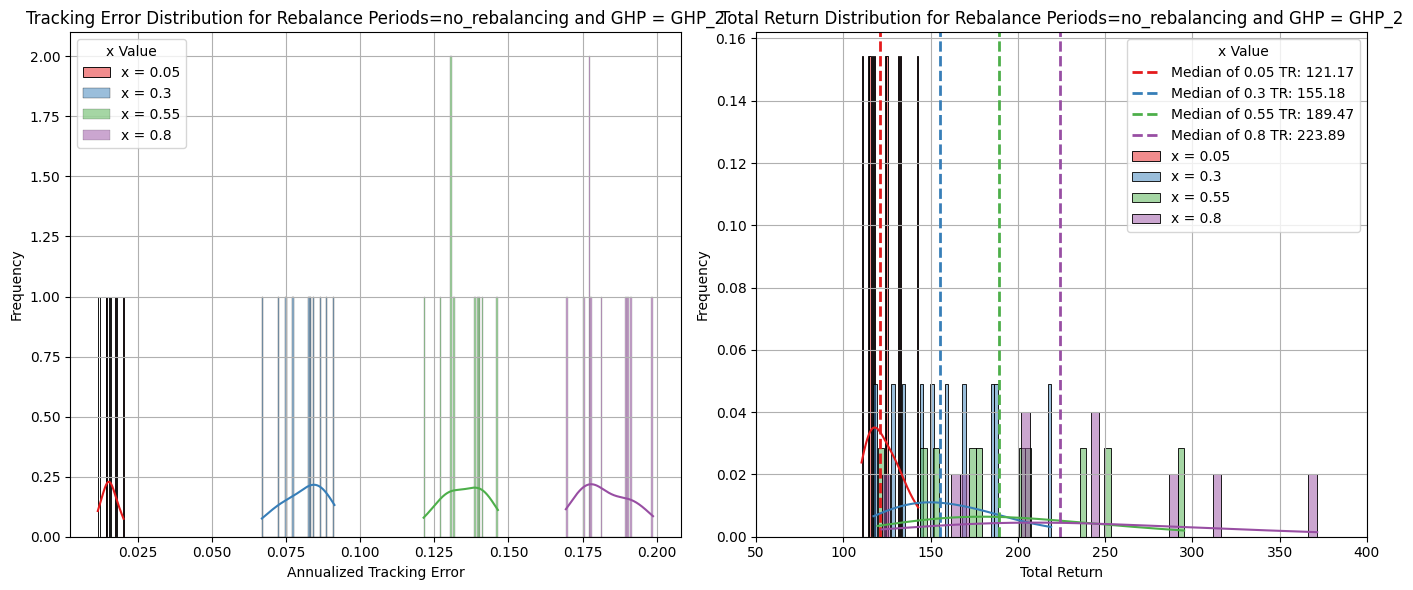

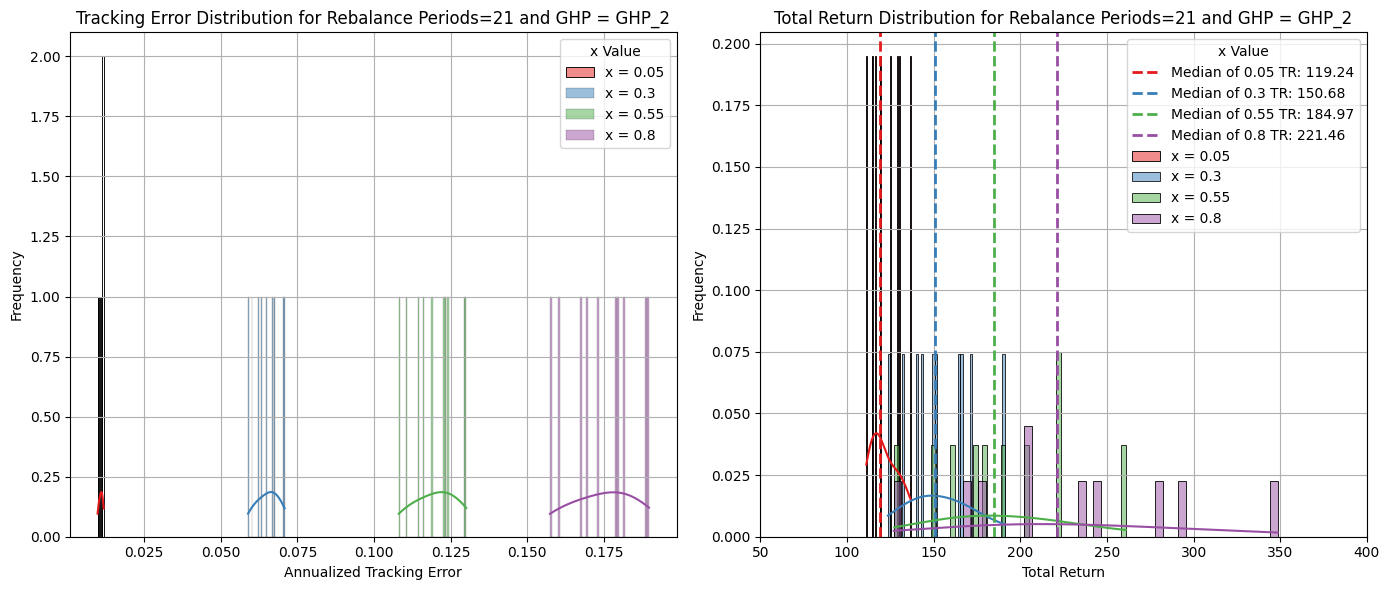

In [15]:
plot_tracking_error_histograms_separate(fund_allocation_simulator.results_df, initial_investment=100)

In [25]:
(1.09**20-1)*0.3

1.38132323033349

Results are wrong. Fund without rebalancing should behave worse

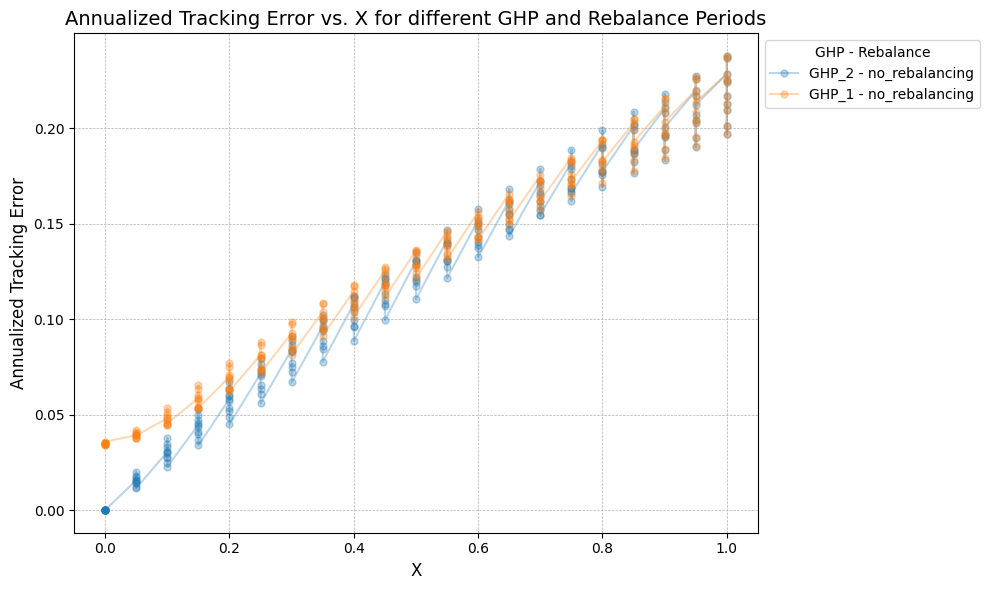

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming 'fund_allocation_simulator.results_df' is the DataFrame
# Get unique values from 'GHP' and 'rebalance_each_X_periods'
ghp_values = fund_allocation_simulator.results_df['GHP'].unique()
rebalance_values = fund_allocation_simulator.results_df['rebalance_each_X_periods'].unique()

# Create a larger figure
plt.figure(figsize=(10, 6))

# Loop through each combination of GHP and rebalance_each_X_periods
for ghp in ghp_values[::-1]:
    for rebalance in [rebalance_values[0]]:
        # Filter the data based on the current combination of GHP and rebalance_each_X_periods
        to_plot_df = fund_allocation_simulator.results_df.loc[
            (fund_allocation_simulator.results_df['GHP'] == ghp) &
            (fund_allocation_simulator.results_df['rebalance_each_X_periods'] == rebalance)
        ]
        
        # Calculate the 1st and 99th percentiles of 'x' for trimming
        lower_percentile = np.percentile(to_plot_df['x'], 1)
        upper_percentile = np.percentile(to_plot_df['x'], 99)
        
        # Trim the data to remove the 1% smallest and largest values of 'x'
        trimmed_df = to_plot_df[(to_plot_df['x'] >= lower_percentile) & (to_plot_df['x'] <= upper_percentile)]
        
        # Plot 'annualized_tracking_err' vs 'x' for the filtered and trimmed data
        plt.plot(trimmed_df['x'], trimmed_df['annualized_tracking_err'], 
                 label=f'{ghp} - {rebalance}', marker='o', linestyle='-', markersize=5,alpha = 0.3)

# Labeling and showing the plot
plt.xlabel('X', fontsize=12)
plt.ylabel('Annualized Tracking Error', fontsize=12)
plt.title('Annualized Tracking Error vs. X for different GHP and Rebalance Periods', fontsize=14)

# Add grid lines for better readability
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Adjust the position of the legend and make sure it is readable
plt.legend(title="GHP - Rebalance", loc='upper left', bbox_to_anchor=(1, 1), fontsize=10)

# Show the plot
plt.tight_layout()  # Adjust layout to avoid clipping of labels and legend
plt.show()


My graphs of fixed mix VS buy and hold are different!!!! They do not look like lionel's graphs. Check with him input parameters

To add:
- new SR
- new portfolios
- what if client invests little by little

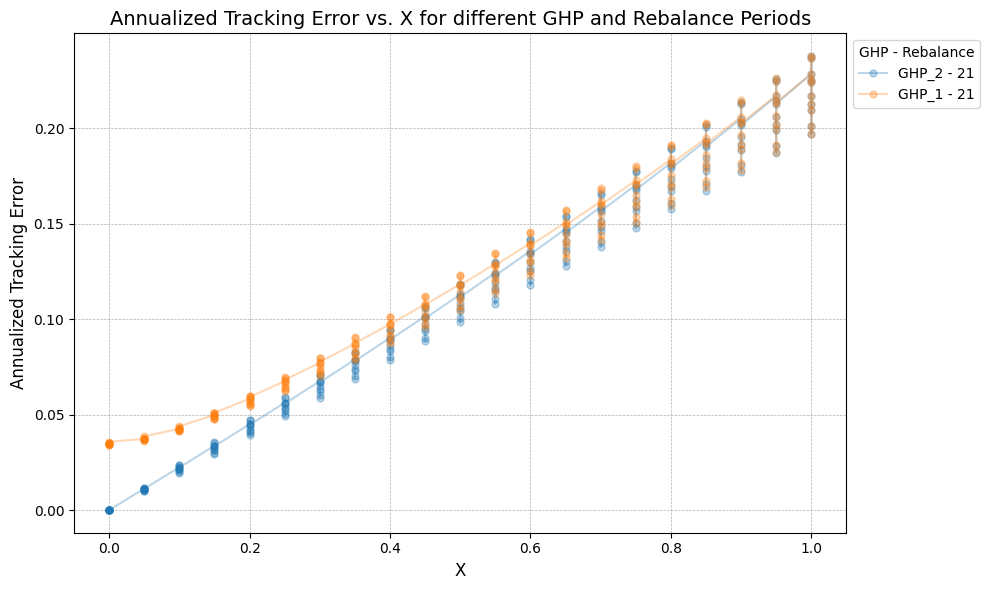

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming 'fund_allocation_simulator.results_df' is the DataFrame
# Get unique values from 'GHP' and 'rebalance_each_X_periods'
ghp_values = fund_allocation_simulator.results_df['GHP'].unique()
rebalance_values = fund_allocation_simulator.results_df['rebalance_each_X_periods'].unique()

# Create a larger figure
plt.figure(figsize=(10, 6))

# Loop through each combination of GHP and rebalance_each_X_periods
for ghp in ghp_values[::-1]:
    for rebalance in [rebalance_values[1]]:
        # Filter the data based on the current combination of GHP and rebalance_each_X_periods
        to_plot_df = fund_allocation_simulator.results_df.loc[
            (fund_allocation_simulator.results_df['GHP'] == ghp) &
            (fund_allocation_simulator.results_df['rebalance_each_X_periods'] == rebalance)
        ]
        
        # Calculate the 1st and 99th percentiles of 'x' for trimming
        lower_percentile = np.percentile(to_plot_df['x'], 1)
        upper_percentile = np.percentile(to_plot_df['x'], 99)
        
        # Trim the data to remove the 1% smallest and largest values of 'x'
        trimmed_df = to_plot_df[(to_plot_df['x'] >= lower_percentile) & (to_plot_df['x'] <= upper_percentile)]
        
        # Plot 'annualized_tracking_err' vs 'x' for the filtered and trimmed data
        plt.plot(trimmed_df['x'], trimmed_df['annualized_tracking_err'], 
                 label=f'{ghp} - {rebalance}', marker='o', linestyle='-', markersize=5,alpha = 0.3)

# Labeling and showing the plot
plt.xlabel('X', fontsize=12)
plt.ylabel('Annualized Tracking Error', fontsize=12)
plt.title('Annualized Tracking Error vs. X for different GHP and Rebalance Periods', fontsize=14)

# Add grid lines for better readability
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Adjust the position of the legend and make sure it is readable
plt.legend(title="GHP - Rebalance", loc='upper left', bbox_to_anchor=(1, 1), fontsize=10)

# Show the plot
plt.tight_layout()  # Adjust layout to avoid clipping of labels and legend
plt.show()


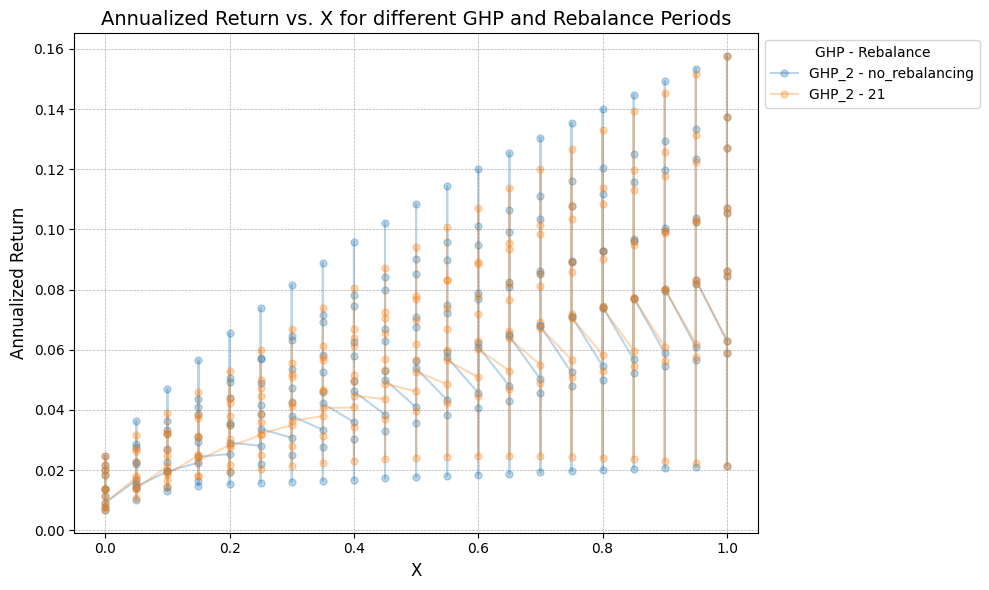

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming 'fund_allocation_simulator.results_df' is the DataFrame
# Get unique values from 'GHP' and 'rebalance_each_X_periods'
ghp_values = fund_allocation_simulator.results_df['GHP'].unique()
rebalance_values = fund_allocation_simulator.results_df['rebalance_each_X_periods'].unique()

# Create a larger figure
plt.figure(figsize=(10, 6))

# Loop through each combination of GHP and rebalance_each_X_periods
for ghp in [ghp_values[1]]:
    for rebalance in rebalance_values:
        # Filter the data based on the current combination of GHP and rebalance_each_X_periods
        to_plot_df = fund_allocation_simulator.results_df.loc[
            (fund_allocation_simulator.results_df['GHP'] == ghp) &
            (fund_allocation_simulator.results_df['rebalance_each_X_periods'] == rebalance)
        ]
        
        # Calculate the 1st and 99th percentiles of 'x' for trimming
        lower_percentile = np.percentile(to_plot_df['x'], 1)
        upper_percentile = np.percentile(to_plot_df['x'], 99)
        
        # Trim the data to remove the 1% smallest and largest values of 'x'
        trimmed_df = to_plot_df[(to_plot_df['x'] >= lower_percentile) & (to_plot_df['x'] <= upper_percentile)]
        
        # Plot 'annualized_tracking_err' vs 'x' for the filtered and trimmed data
        plt.plot(trimmed_df['x'], trimmed_df['annualized_return'], 
                 label=f'{ghp} - {rebalance}', marker='o', linestyle='-', markersize=5,alpha = 0.3)

# Labeling and showing the plot
plt.xlabel('X', fontsize=12)
plt.ylabel('Annualized Return', fontsize=12)
plt.title('Annualized Return vs. X for different GHP and Rebalance Periods', fontsize=14)

# Add grid lines for better readability
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Adjust the position of the legend and make sure it is readable
plt.legend(title="GHP - Rebalance", loc='upper left', bbox_to_anchor=(1, 1), fontsize=10)

# Show the plot
plt.tight_layout()  # Adjust layout to avoid clipping of labels and legend
plt.show()


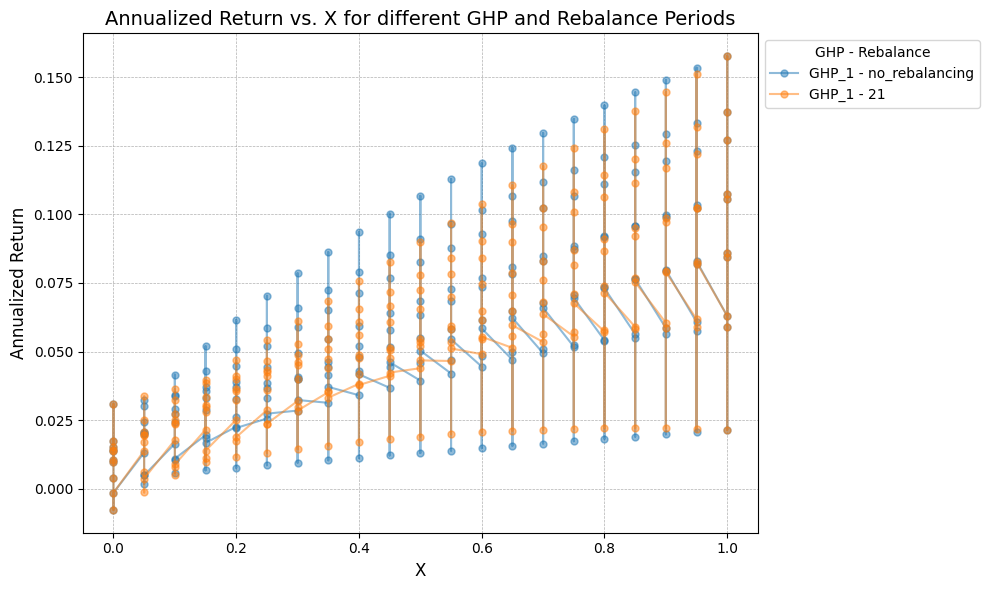

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming 'fund_allocation_simulator.results_df' is the DataFrame
# Get unique values from 'GHP' and 'rebalance_each_X_periods'
ghp_values = fund_allocation_simulator.results_df['GHP'].unique()
rebalance_values = fund_allocation_simulator.results_df['rebalance_each_X_periods'].unique()

# Create a larger figure
plt.figure(figsize=(10, 6))

# Loop through each combination of GHP and rebalance_each_X_periods
for ghp in [ghp_values[0]]:
    for rebalance in rebalance_values:
        # Filter the data based on the current combination of GHP and rebalance_each_X_periods
        to_plot_df = fund_allocation_simulator.results_df.loc[
            (fund_allocation_simulator.results_df['GHP'] == ghp) &
            (fund_allocation_simulator.results_df['rebalance_each_X_periods'] == rebalance)
        ]
        
        # Calculate the 1st and 99th percentiles of 'x' for trimming
        lower_percentile = np.percentile(to_plot_df['x'], 1)
        upper_percentile = np.percentile(to_plot_df['x'], 99)
        
        # Trim the data to remove the 1% smallest and largest values of 'x'
        trimmed_df = to_plot_df[(to_plot_df['x'] >= lower_percentile) & (to_plot_df['x'] <= upper_percentile)]
        
        # Plot 'annualized_tracking_err' vs 'x' for the filtered and trimmed data
        plt.plot(trimmed_df['x'], trimmed_df['annualized_return'], 
                 label=f'{ghp} - {rebalance}', marker='o', linestyle='-', markersize=5,alpha = 0.5)

# Labeling and showing the plot
plt.xlabel('X', fontsize=12)
plt.ylabel('Annualized Return', fontsize=12)
plt.title('Annualized Return vs. X for different GHP and Rebalance Periods', fontsize=14)

# Add grid lines for better readability
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Adjust the position of the legend and make sure it is readable
plt.legend(title="GHP - Rebalance", loc='upper left', bbox_to_anchor=(1, 1), fontsize=10)

# Show the plot
plt.tight_layout()  # Adjust layout to avoid clipping of labels and legend
plt.show()


Look at summary statistics of the final table

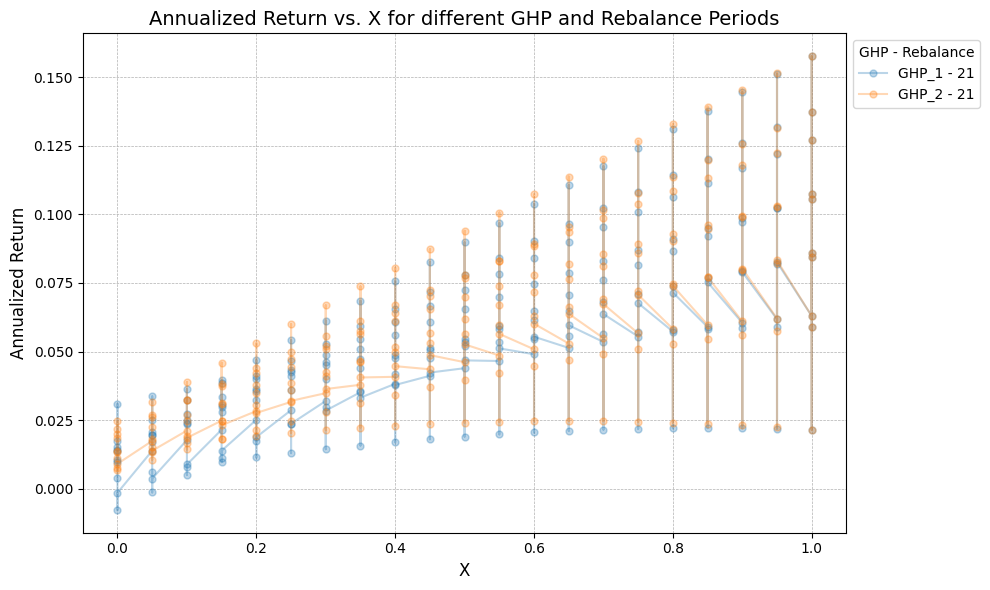

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming 'fund_allocation_simulator.results_df' is the DataFrame
# Get unique values from 'GHP' and 'rebalance_each_X_periods'
ghp_values = fund_allocation_simulator.results_df['GHP'].unique()
rebalance_values = fund_allocation_simulator.results_df['rebalance_each_X_periods'].unique()

# Create a larger figure
plt.figure(figsize=(10, 6))

# Loop through each combination of GHP and rebalance_each_X_periods
for ghp in ghp_values:
    for rebalance in [rebalance_values[1]]:
        # Filter the data based on the current combination of GHP and rebalance_each_X_periods
        to_plot_df = fund_allocation_simulator.results_df.loc[
            (fund_allocation_simulator.results_df['GHP'] == ghp) &
            (fund_allocation_simulator.results_df['rebalance_each_X_periods'] == rebalance)
        ]
        
        # Calculate the 1st and 99th percentiles of 'x' for trimming
        lower_percentile = np.percentile(to_plot_df['x'], 1)
        upper_percentile = np.percentile(to_plot_df['x'], 99)
        
        # Trim the data to remove the 1% smallest and largest values of 'x'
        trimmed_df = to_plot_df[(to_plot_df['x'] >= lower_percentile) & (to_plot_df['x'] <= upper_percentile)]
        
        # Plot 'annualized_tracking_err' vs 'x' for the filtered and trimmed data
        plt.plot(trimmed_df['x'], trimmed_df['annualized_return'], 
                 label=f'{ghp} - {rebalance}', marker='o', linestyle='-', markersize=5,alpha = 0.3)

# Labeling and showing the plot
plt.xlabel('X', fontsize=12)
plt.ylabel('Annualized Return', fontsize=12)
plt.title('Annualized Return vs. X for different GHP and Rebalance Periods', fontsize=14)

# Add grid lines for better readability
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Adjust the position of the legend and make sure it is readable
plt.legend(title="GHP - Rebalance", loc='upper left', bbox_to_anchor=(1, 1), fontsize=10)

# Show the plot
plt.tight_layout()  # Adjust layout to avoid clipping of labels and legend
plt.show()


Find MDD, 

1.7857142857142856